Initiating Breakout Factor Diagnostic...
Processing Snapshot: 2026-03-31

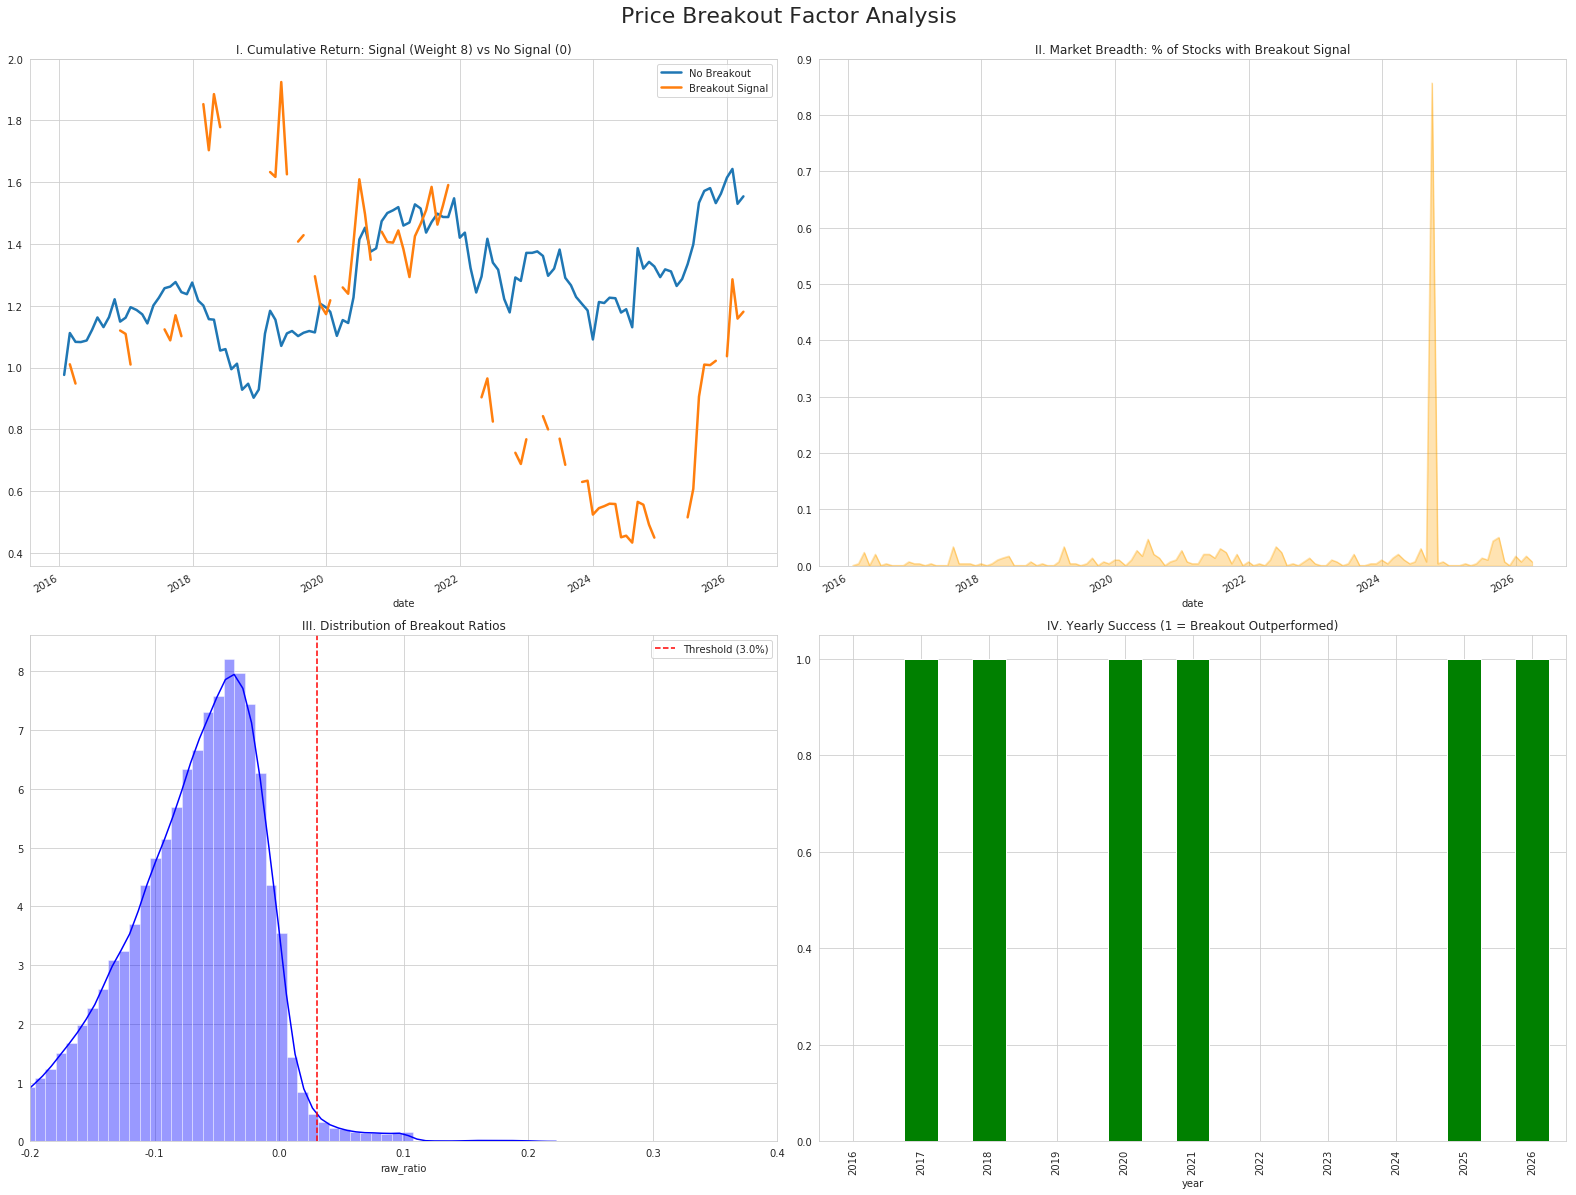


Average IC: 0.0008 | Avg Monthly Breakout Stocks: 6.5


In [1]:
'''
This factor is based on the "Price Breakout" logic, a classic trend-following indicator.
It identifies stocks whose current closing price has exceeded the recent high 
(e.g., 20-day or 60-day high) by a specific threshold (e.g., 3%).

Unlike oscillating factors, this is a binary "Signal Factor." 
The scoring system assigns a fixed weight (8) only when the breakout condition is met. 
This diagnostic focuses on "Breakout Reliability" (Success Rate) and whether 
buying the breakout in the 000300.XSHG universe leads to sustained momentum 
or "Bull Traps" (False Breakouts).
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
import warnings

# 1. Environment Configuration
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 2. Parameters and Backtest Engine
start_date, end_date = "2016-01-01", "2026-04-01"
all_days = get_trade_days(start_date, end_date)
ts_series = pd.to_datetime(pd.Series(all_days))
rebal_dates = ts_series.groupby([ts_series.dt.year, ts_series.dt.month]).last()
date_list = [d.strftime('%Y-%m-%d') for d in rebal_dates]

# Simulation Configuration
breakout_p = 20      # Lookback period for high
threshold = 0.03     # 3% breakout threshold
weight = 8

dataset = []
print("Initiating Breakout Factor Diagnostic...")

for i in range(len(date_list) - 1):
    t0, t1 = date_list[i], date_list[i+1]
    universe = get_index_stocks('000300.XSHG', date=t0)
    print("\rProcessing Snapshot: {}".format(t0), end="")
    
    # Fetch high and close prices
    prices = get_price(universe, end_date=t0, count=breakout_p + 1, fields=['high', 'close'], panel=False)
    
    res = []
    for s in universe:
        s_data = prices[prices['code'] == s]
        if len(s_data) < breakout_p: continue
        
        # Calculate Breakout Logic
        # recent_high is the max of 'high' excluding the last candle
        recent_high = s_data['high'].iloc[:-1].max()
        current_close = s_data['close'].iloc[-1]
        breakout_ratio = (current_close - recent_high) / recent_high
        
        # Binary Scoring
        score = weight if breakout_ratio >= threshold else 0
        res.append({'code': s, 'raw_ratio': breakout_ratio, 'score': score})
    
    if not res: continue
    
    df = pd.DataFrame(res)
    # Forward return calculation
    p0 = get_price(list(df['code']), end_date=t0, count=1, fields='close', panel=False).set_index('code')['close']
    p1 = get_price(list(df['code']), end_date=t1, count=1, fields='close', panel=False).set_index('code')['close']
    
    df['fwd_ret'] = df['code'].map((p1 / p0) - 1)
    df['date'] = pd.to_datetime(t0)
    dataset.append(df)

master_df = pd.concat(dataset, ignore_index=True).dropna()
master_df['year'] = master_df['date'].dt.year

# 3. Visualization for Binary Factors
# Since this is binary, we split into "Breakout" vs "Non-Breakout"
ic_ts = master_df.groupby('date').apply(lambda g: g['score'].corr(g['fwd_ret']))
group_stats = master_df.groupby(['date', 'score'])['fwd_ret'].mean().unstack()

fig = plt.figure(figsize=(22, 18))
plt.suptitle('Price Breakout Factor Analysis', fontsize=22, y=0.95)

# I. Cumulative Return (Breakout vs No Breakout)
ax1 = plt.subplot(2, 2, 1)
(1 + group_stats).cumprod().plot(ax=ax1, lw=2.5)
ax1.set_title("I. Cumulative Return: Signal (Weight 8) vs No Signal (0)")
ax1.legend(["No Breakout", "Breakout Signal"])

# II. Signal Frequency (How many stocks break out each month?)
ax2 = plt.subplot(2, 2, 2)
signal_freq = master_df[master_df['score'] > 0].groupby('date')['code'].count() / master_df.groupby('date')['code'].count()
signal_freq.plot(ax=ax2, color='orange', kind='area', alpha=0.3)
ax2.set_title("II. Market Breadth: % of Stocks with Breakout Signal")

# III. Distribution of Breakout Ratios
ax3 = plt.subplot(2, 2, 3)
sns.distplot(master_df['raw_ratio'], bins=100, color='blue', ax=ax3)
ax3.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold*100}%)')
ax3.set_xlim(-0.2, 0.4)
ax3.set_title("III. Distribution of Breakout Ratios")
ax3.legend()

# IV. Win Rate by Year
ax4 = plt.subplot(2, 2, 4)
# Win rate defined as: (Breakout Mean Ret > Non-Breakout Mean Ret)
master_df['success'] = master_df['score'] > 0
yearly_win_rate = master_df.groupby('year').apply(
    lambda x: (x[x['score'] > 0]['fwd_ret'].mean() > x[x['score'] == 0]['fwd_ret'].mean())
)
yearly_win_rate.astype(int).plot(kind='bar', color='green', ax=ax4)
ax4.set_title("IV. Yearly Success (1 = Breakout Outperformed)")

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

print("\nAverage IC: {:.4f} | Avg Monthly Breakout Stocks: {:.1f}".format(
    ic_ts.mean(), master_df[master_df['score'] > 0].groupby('date')['code'].count().mean()
))